In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

sns.set(style="whitegrid")

pd.set_option("display.max_columns",None)

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Telco-Customer-Churn.csv to Telco-Customer-Churn.csv


In [3]:
df = pd.read_csv(next(iter(uploaded)))

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print("Shape :",df.shape)

print("\nColumns")

print(df.columns)

print("\nInformation")

df.info()

print("\nSummary")

display(df.describe(include='all'))

Shape : (7043, 21)

Columns
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [5]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [6]:
print("Duplicate Rows :",df.duplicated().sum())

Duplicate Rows : 0


In [7]:
df.drop_duplicates(inplace=True)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"],errors="coerce")

df["TotalCharges"].fillna(df["TotalCharges"].median(),inplace=True)

/tmp/ipykernel_1131/2416547935.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(),inplace=True)


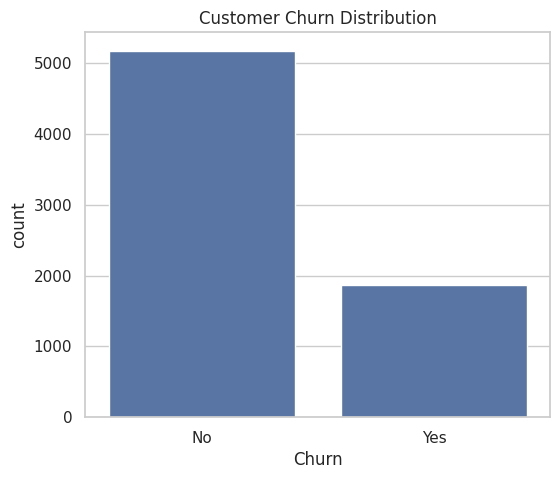

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [8]:
plt.figure(figsize=(6,5))

sns.countplot(data=df,x="Churn")

plt.title("Customer Churn Distribution")

plt.show()

print(df["Churn"].value_counts(normalize=True)*100)

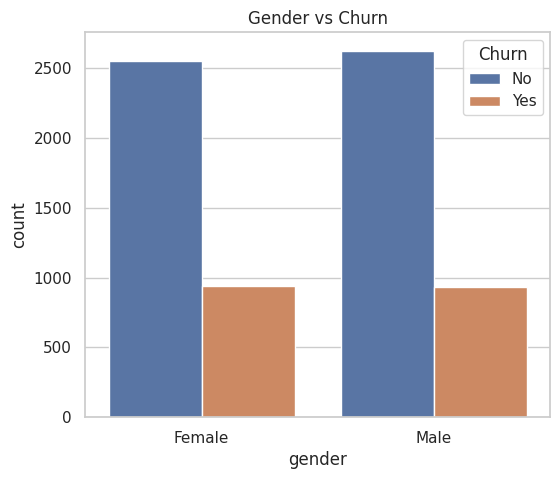

In [9]:
plt.figure(figsize=(6,5))

sns.countplot(data=df,x="gender",hue="Churn")

plt.title("Gender vs Churn")

plt.show()

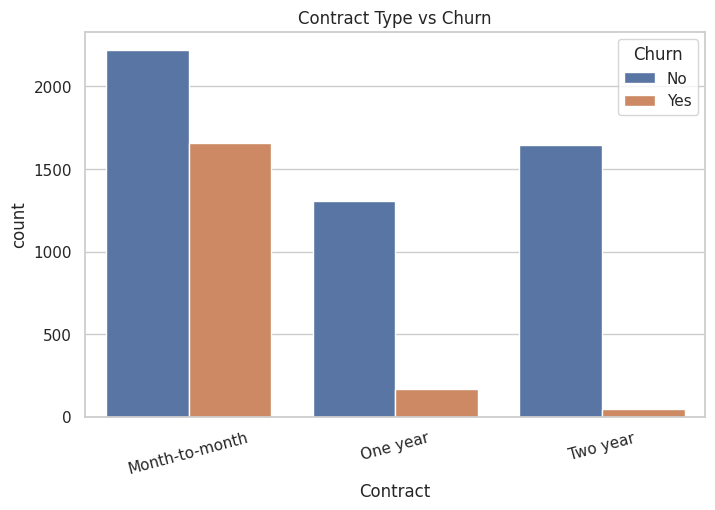

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,x="Contract",hue="Churn")

plt.title("Contract Type vs Churn")

plt.xticks(rotation=15)

plt.show()

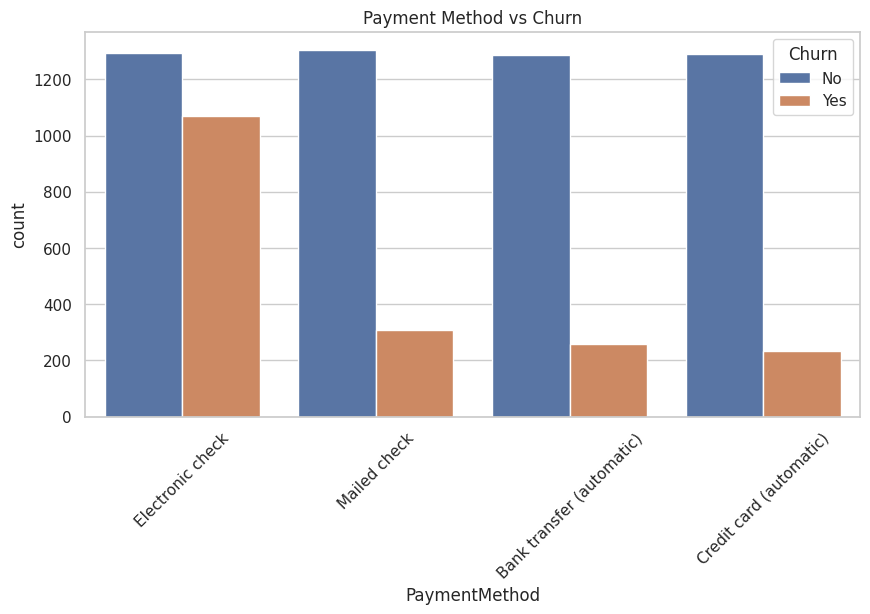

In [11]:
plt.figure(figsize=(10,5))

sns.countplot(data=df,x="PaymentMethod",hue="Churn")

plt.xticks(rotation=45)

plt.title("Payment Method vs Churn")

plt.show()

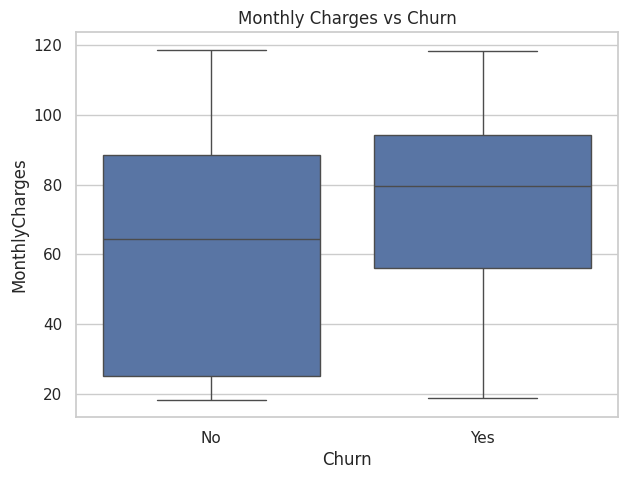

In [12]:
plt.figure(figsize=(7,5))

sns.boxplot(data=df,x="Churn",y="MonthlyCharges")

plt.title("Monthly Charges vs Churn")

plt.show()

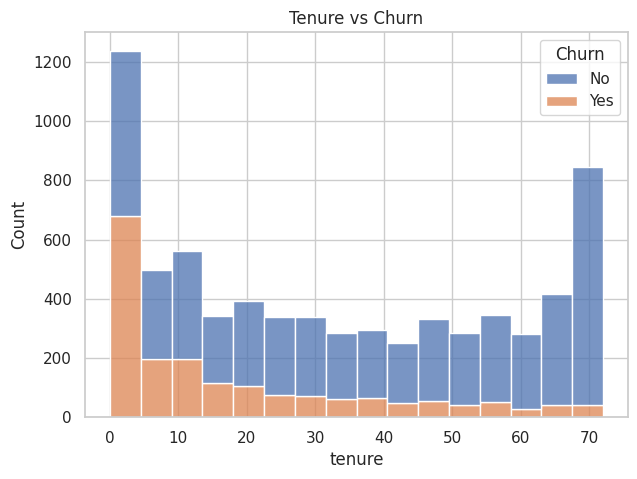

In [13]:
plt.figure(figsize=(7,5))

sns.histplot(data=df,x="tenure",hue="Churn",multiple="stack")

plt.title("Tenure vs Churn")

plt.show()

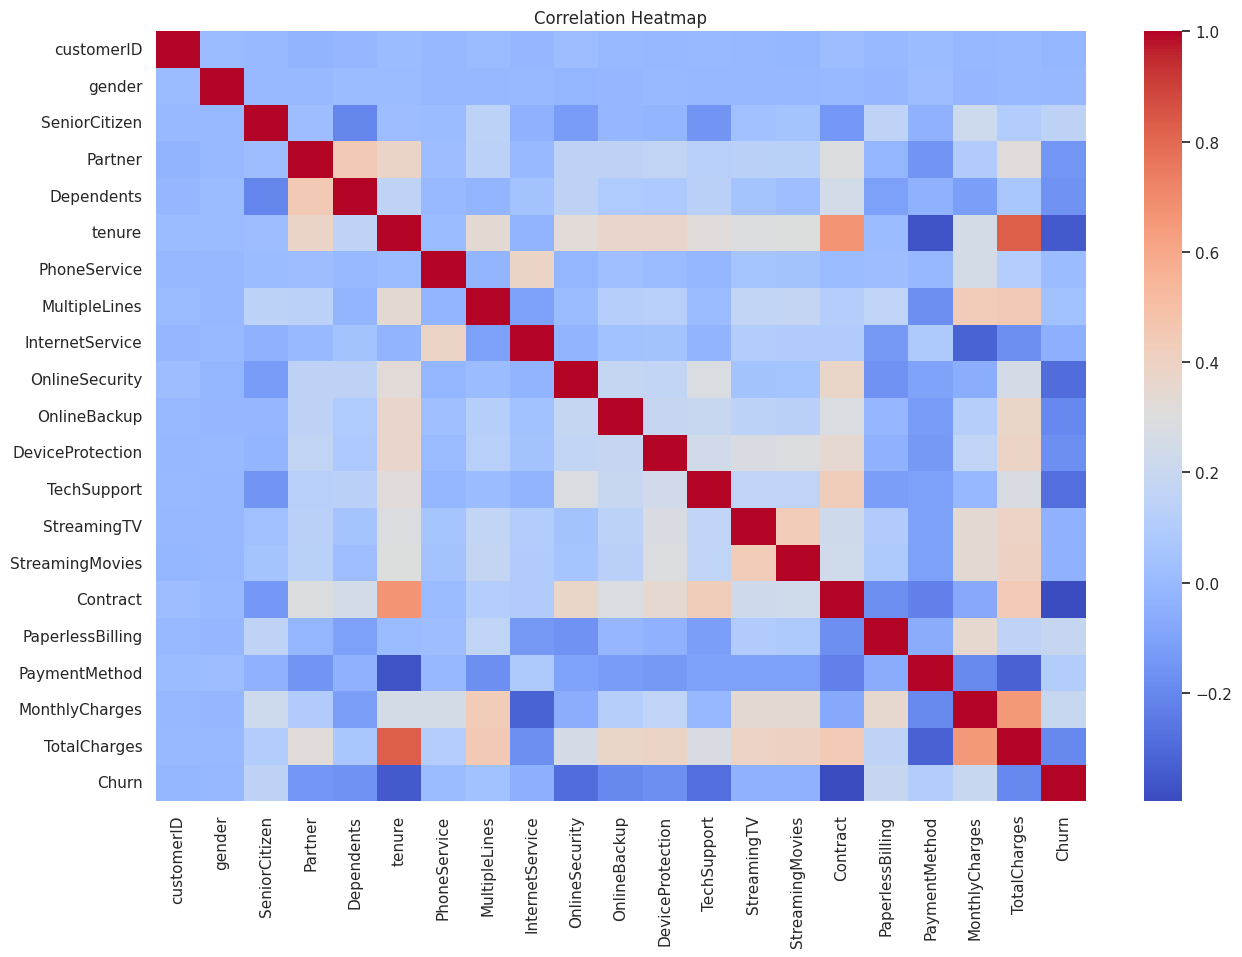

In [14]:
data=df.copy()

encoder=LabelEncoder()

for col in data.columns:

    if data[col].dtype=="object":

        data[col]=encoder.fit_transform(data[col].astype(str))

plt.figure(figsize=(15,10))

sns.heatmap(data.corr(),annot=False,cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

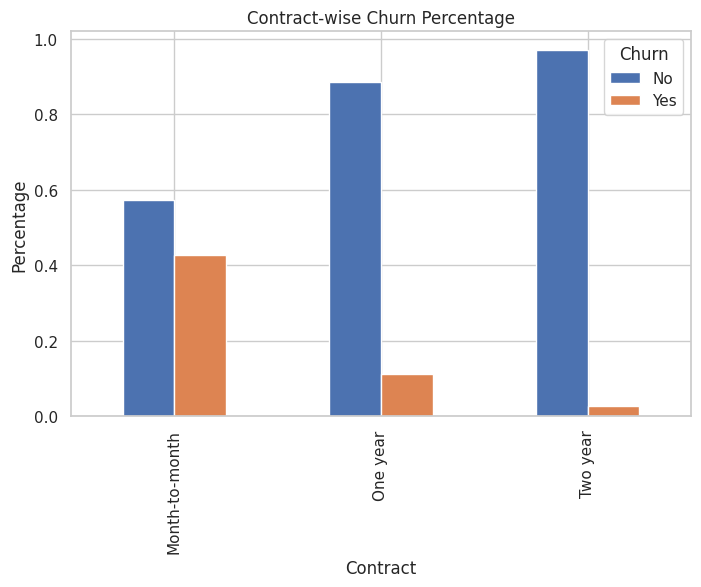

In [15]:
contract=df.groupby("Contract")["Churn"].value_counts(normalize=True).unstack()

contract.plot(kind="bar",figsize=(8,5))

plt.ylabel("Percentage")

plt.title("Contract-wise Churn Percentage")

plt.show()

In [16]:
corr=data.corr()["Churn"].sort_values(ascending=False)

print(corr)

Churn               1.000000
MonthlyCharges      0.193356
PaperlessBilling    0.191825
SeniorCitizen       0.150889
PaymentMethod       0.107062
MultipleLines       0.038037
PhoneService        0.011942
gender             -0.008612
customerID         -0.017447
StreamingTV        -0.036581
StreamingMovies    -0.038492
InternetService    -0.047291
Partner            -0.150448
Dependents         -0.164221
DeviceProtection   -0.178134
OnlineBackup       -0.195525
TotalCharges       -0.199037
TechSupport        -0.282492
OnlineSecurity     -0.289309
tenure             -0.352229
Contract           -0.396713
Name: Churn, dtype: float64


In [17]:
print("="*60)

print("CUSTOMER CHURN ANALYSIS")

print("="*60)

print()

print("1. Customers with Month-to-Month contracts show higher churn.")

print()

print("2. Customers having low tenure are more likely to leave.")

print()

print("3. High Monthly Charges increase churn probability.")

print()

print("4. Long-term contracts reduce churn.")

print()

print("5. Electronic Check users churn more frequently.")

print()

print("6. Senior Citizens generally have higher churn.")

print()

print("="*60)

CUSTOMER CHURN ANALYSIS

1. Customers with Month-to-Month contracts show higher churn.

2. Customers having low tenure are more likely to leave.

3. High Monthly Charges increase churn probability.

4. Long-term contracts reduce churn.

5. Electronic Check users churn more frequently.

6. Senior Citizens generally have higher churn.



In [18]:
recommendations = [

"Offer discounts to month-to-month customers.",

"Provide loyalty rewards for long-term customers.",

"Improve customer support quality.",

"Offer personalized retention campaigns.",

"Reduce monthly charges through bundled plans.",

"Monitor new customers during the first six months."

]

for i,r in enumerate(recommendations,1):

    print(f"{i}. {r}")

1. Offer discounts to month-to-month customers.
2. Provide loyalty rewards for long-term customers.
3. Improve customer support quality.
4. Offer personalized retention campaigns.
5. Reduce monthly charges through bundled plans.
6. Monitor new customers during the first six months.


In [19]:
df.to_csv("Customer_Churn_Analysis.csv",index=False)

print("Analysis Completed Successfully")

Analysis Completed Successfully


In [20]:
from google.colab import files

files.download("Customer_Churn_Analysis.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>